# Project 2 — Clinical Risk Analysis

**Objective:**  
Analyze synthetic patient EHR data to identify risk factors based on age, encounters, conditions, and medications.  
Compute a simple risk score and categorize patients into Low, Medium, and High risk.  

**Tools used:** Python, Pandas

## Step 0 — Import Libraries

Import necessary Python libraries for data manipulation.  
Pandas is used to load CSV files and perform all analysis.

In [1]:
import pandas as pd

In [2]:
# Test Pandas is working
print(pd.__version__)

3.0.1


## Step 1 — Load Datasets & Quick Check

Load all datasets into Pandas DataFrames and preview the first few rows:  
- **patients.csv** — patient demographics  
- **encounters.csv** — hospital encounters  
- **conditions.csv** — patient conditions  
- **medications.csv** — prescribed medications  

Use `.head()` to inspect the data and ensure it loaded correctly.

In [3]:
# Load datasets
patients = pd.read_csv("patients.csv")
encounters = pd.read_csv("encounters.csv")
conditions = pd.read_csv("conditions.csv")
medications = pd.read_csv("medications.csv")

# Quick check
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,NaN,999-76-6866,S99984236,X19277260X,Mr.,José Eduardo181,Gómez206,NaN,...,Marigot Saint Andrew Parish DM,427 Balistreri Way Unit 19,Chicopee,Massachusetts,Hampden County,1013.0,42.228354,-72.562951,271227.08,1334.88
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,NaN,999-73-5361,S99962402,X88275464X,Mr.,Milo271,Feil794,NaN,...,Danvers Massachusetts US,422 Farrell Path Unit 69,Somerville,Massachusetts,Middlesex County,2143.0,42.360697,-71.126531,793946.01,3204.49
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,NaN,999-27-3385,S99972682,X73754411X,Mr.,Jayson808,Fadel536,NaN,...,Springfield Massachusetts US,1056 Harris Lane Suite 70,Chicopee,Massachusetts,Hampden County,1020.0,42.181642,-72.608842,574111.90,2606.40
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,NaN,999-85-4926,S99974448,X40915583X,Mrs.,Mariana775,Rutherford999,NaN,...,Yarmouth Massachusetts US,999 Kuhn Forge,Lowell,Massachusetts,Middlesex County,1851.0,42.636143,-71.343255,935630.30,8756.19
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,NaN,999-60-7372,S99915787,X86772962X,Mr.,Gregorio366,Auer97,NaN,...,Patras Achaea GR,1050 Lindgren Extension Apt 38,Boston,Massachusetts,Suffolk County,2135.0,42.352434,-71.028610,598763.07,3772.20


## Step 2a — Clean Patients Dataset

Keep only the necessary columns from patients:  
- `Id` → renamed to `patient_id`  
- `BIRTHDATE`  
- `GENDER`  

This ensures patient demographics are ready for analysis.

In [4]:
# Keep only the columns we need
patients = patients[["Id", "BIRTHDATE", "GENDER"]].rename(columns={"Id": "patient_id"})

In [5]:
patients.head()

,patient_id,BIRTHDATE,GENDER
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,M
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,M
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,M
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,F
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,M


## Step 2b — Keep Only Patient Column for Counting

For the encounters, conditions, and medications datasets, we only need the `PATIENT` column:  
- This column is sufficient to count the number of encounters, conditions, or medications per patient.  
- Reduces unnecessary data and simplifies subsequent analysis.

In [6]:
# For counting, only patient column matters
encounters = encounters[["PATIENT"]]
conditions = conditions[["PATIENT"]]
medications = medications[["PATIENT"]]

## Step 3 — Calculate Patient Age

Convert the `BIRTHDATE` column to datetime format and calculate each patient’s age as of 2024.  

This allows us to use age as a factor in risk scoring and later analysis.

In [7]:
# Convert BIRTHDATE to datetime
patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"])

# Calculate age as of 2024
patients["age"] = 2024 - patients["BIRTHDATE"].dt.year

# Optional: check first 5 rows
patients.head()

,patient_id,BIRTHDATE,GENDER,age
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,M,35
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,M,41
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,M,32
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,F,46
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,M,28


### Step 4a — Count Encounters

Group the encounters dataset by `PATIENT` to calculate the total number of hospital encounters per patient.  
This will be used later in the risk score calculation.

In [8]:
# Count how many encounters each patient has
encounter_count = encounters.groupby("PATIENT").size().reset_index(name="encounter_count")
encounter_count = encounter_count.rename(columns={"PATIENT": "patient_id"})

# Optional check
encounter_count.head()

,patient_id,encounter_count
0,00185faa-2760-4218-9bf5-db301acf8274,22
1,0042862c-9889-4a2e-b782-fac1e540ecb4,21
2,0047123f-12e7-486c-82df-53b3a450e365,21
3,010d4a3a-2316-45ed-ae15-16f01c611674,13
4,01207ecd-9dff-4754-8887-4652eda231e2,6


### Step 4b — Count Conditions

Group the conditions dataset by `PATIENT` to calculate the total number of conditions per patient.  
This count contributes to the patient’s risk score.

In [9]:
condition_count = conditions.groupby("PATIENT").size().reset_index(name="condition_count")
condition_count = condition_count.rename(columns={"PATIENT": "patient_id"})

condition_count.head()

,patient_id,condition_count
0,00185faa-2760-4218-9bf5-db301acf8274,5
1,0042862c-9889-4a2e-b782-fac1e540ecb4,4
2,0047123f-12e7-486c-82df-53b3a450e365,6
3,010d4a3a-2316-45ed-ae15-16f01c611674,3
4,0149d553-f571-4e99-867e-fcb9625d07c2,9


### Step 4c — Count Medications

Group the medications dataset by `PATIENT` to calculate the total number of medications per patient.  
This will be included in the patient’s risk score.

In [10]:
medication_count = medications.groupby("PATIENT").size().reset_index(name="medication_count")
medication_count = medication_count.rename(columns={"PATIENT": "patient_id"})

medication_count.head()

,patient_id,medication_count
0,00185faa-2760-4218-9bf5-db301acf8274,11
1,0042862c-9889-4a2e-b782-fac1e540ecb4,3
2,0047123f-12e7-486c-82df-53b3a450e365,2
3,010d4a3a-2316-45ed-ae15-16f01c611674,4
4,0149d553-f571-4e99-867e-fcb9625d07c2,8


## Step 5 — Merge All Data

Combine patient demographics with encounter, condition, and medication counts into a single table.  

- Merge on `patient_id`/`PATIENT` to ensure each patient has their counts attached.  
- Fill missing values with 0 for patients with no encounters, conditions, or medications.  
- This creates a complete dataset ready for risk scoring.

In [11]:
# Start with patients table
analysis_table = patients.merge(encounter_count, on="patient_id", how="left")
analysis_table = analysis_table.merge(condition_count, on="patient_id", how="left")
analysis_table = analysis_table.merge(medication_count, on="patient_id", how="left")

# Replace any missing values with 0
analysis_table = analysis_table.fillna(0)

# Optional: check first 5 rows
analysis_table.head()

,patient_id,BIRTHDATE,GENDER,age,encounter_count,condition_count,medication_count
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,M,35,6,3.0,2.0
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,M,41,6,1.0,1.0
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,M,32,12,4.0,3.0
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,F,46,17,3.0,7.0
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,M,28,13,5.0,1.0


## Step 6 — Summary Statistics

Generate basic summary statistics for numeric columns:  
- `age`  
- `encounter_count`  
- `condition_count`  
- `medication_count`  

This provides an overview of the dataset distribution and helps identify patterns or anomalies before further analysis.

In [12]:
# Summary statistics for numeric columns
analysis_table[["age", "encounter_count", "condition_count", "medication_count"]].describe()

,age,encounter_count,condition_count,medication_count
count,1171.000000,1171.000000,1171.000000,1171.000000
mean,48.872758,45.555935,7.152861,36.711358
std,26.702189,97.667765,4.147457,141.420814
min,4.000000,2.000000,0.000000,0.000000
25%,27.000000,16.000000,4.000000,3.000000
50%,48.000000,27.000000,7.000000,7.000000
75%,68.000000,54.000000,10.000000,31.000000
max,115.000000,2006.000000,25.000000,3313.000000


## Step 7 — Gender Distribution

Analyze the patient population by gender:  

1. **Counts:** Determine how many patients belong to each gender category.  
2. **Percentages:** Compute the proportion of each gender relative to the total population.  

This provides both absolute and relative views of the gender composition in the dataset, useful for understanding population balance and identifying potential biases.

In [13]:
# Count of patients by gender
analysis_table["GENDER"].value_counts()

GENDER
F    609
M    562
Name: count, dtype: int64

In [14]:
analysis_table["GENDER"].value_counts(normalize=True) * 100

GENDER
F    52.006832
M    47.993168
Name: proportion, dtype: float64

## Step 8 — Average Encounters by Age Group

Divide patients into age groups (0–20, 21–40, 41–60, 61–80, 81–100) and calculate the **average number of encounters** for each group.  

- Helps identify which age groups have higher healthcare utilization.  
- Provides insight into the relationship between age and hospital encounters.

In [15]:
# Create age groups
age_groups = pd.cut(analysis_table["age"], bins=[0,20,40,60,80,100])

# Average encounters per age group
analysis_table.groupby(age_groups)["encounter_count"].mean()

age
(0, 20]      19.226131
(20, 40]     34.544521
(40, 60]     38.038596
(60, 80]     48.768595
(80, 100]    67.597938
Name: encounter_count, dtype: float64

## Step 9 — Average Encounters by Number of Conditions

Group patients based on the number of conditions they have and calculate the **average number of encounters** per group:  

- Helps understand how the **number of conditions impacts healthcare utilization**.  
- Provides insight into which patient groups may have higher clinical risk.

In [16]:
# Group patients by number of conditions
condition_groups = pd.cut(analysis_table["condition_count"], bins=[0,1,2,3,4,10])
analysis_table.groupby(condition_groups)["encounter_count"].mean()

condition_count
(0, 1]     11.793103
(1, 2]     13.656716
(2, 3]     18.855856
(3, 4]     24.765217
(4, 10]    38.549180
Name: encounter_count, dtype: float64

## Step 10 — Average Medications by Age Group

Using the previously defined age groups, calculate the **average number of medications** per age group:  

- Helps identify which age groups are prescribed more medications.  
- Provides insight into medication patterns across different ages, which can contribute to risk assessment.

In [17]:
# Average medications per age group
analysis_table.groupby(age_groups)["medication_count"].mean()

age
(0, 20]       5.462312
(20, 40]     11.664384
(40, 60]     26.863158
(60, 80]     42.107438
(80, 100]    80.134021
Name: medication_count, dtype: float64

## Step 11 — Risk Score Calculation

A risk score is calculated for each patient using key indicators of clinical complexity:

- Age  
- Number of diagnosed conditions  
- Number of healthcare encounters  
- Number of medications  

Each factor contributes one point when it exceeds a defined threshold.  
The resulting values are stored in a new column called **`risk_score`**, which represents the total risk points for each patient. This numeric score will later be used to classify patients into Low, Medium, and High risk categories.

In [18]:
# Risk score calculation based on clinical factors
def risk_score(row):
    score = 0
    if row["age"] > 75:
        score += 1
    if row["condition_count"] >= 5:
        score += 1
    if row["encounter_count"] >= 20:
        score += 1
    if row["medication_count"] >= 15:
        score += 1
    return score

# Apply the risk score
analysis_table["risk_score"] = analysis_table.apply(risk_score, axis=1)

## Step 12 — Assign Risk Levels

Transform the numeric `risk_score` into categorical **risk levels** to classify patients based on their clinical complexity:

- **0–1** → Low  
- **2–3** → Medium  
- **4+** → High  

Counting the number of patients in each risk level provides an overview of the distribution of risk across the population.

In [19]:
analysis_table["risk_level"] = pd.cut(
    analysis_table["risk_score"],
    bins=[-1,1,2,4],   # Low: 0-1, Medium: 2, High: 3-4
    labels=["Low", "Medium", "High"]
)

# Check counts
print(analysis_table["risk_level"].value_counts())

risk_level
High      433
Low       427
Medium    311
Name: count, dtype: int64


## Step 13 — Export Final Analysis

Save the completed `analysis_table` to a CSV file:  

- File name: `Clinical_Risk_Analysis.csv`  
- Includes all processed columns, risk scores, and risk levels  
- Makes the dataset ready for reporting or further analysis

In [20]:
# Export the updated analysis table to a CSV file
analysis_table.to_csv("Clinical_Risk_Analysis.csv", index=False)

## Step 14 — Verify Exported CSV

Read the exported CSV file back into Pandas and preview the first few rows:  

- Confirms that all processed columns, risk scores, and risk levels were saved correctly.  
- Ensures the dataset is ready for reporting or further analysis.

In [21]:
# Optional: read back first few rows to confirm
pd.read_csv("Clinical_Risk_Analysis.csv").head()

,patient_id,BIRTHDATE,GENDER,age,encounter_count,condition_count,medication_count,risk_score,risk_level
0,1d604da9-9a81-4ba9-80c2-de3375d59b40,1989-05-25,M,35,6,3.0,2.0,0,Low
1,034e9e3b-2def-4559-bb2a-7850888ae060,1983-11-14,M,41,6,1.0,1.0,0,Low
2,10339b10-3cd1-4ac3-ac13-ec26728cb592,1992-06-02,M,32,12,4.0,3.0,0,Low
3,8d4c4326-e9de-4f45-9a4c-f8c36bff89ae,1978-05-27,F,46,17,3.0,7.0,0,Low
4,f5dcd418-09fe-4a2f-baa0-3da800bd8c3a,1996-10-18,M,28,13,5.0,1.0,1,Low


## Visualizations
This section provides visual insights from the clinical risk analysis, including risk distribution, age-based trends, and clinical intensity.

### Patient Count by Risk Level
Shows how many patients fall into Low, Medium, and High risk categories.

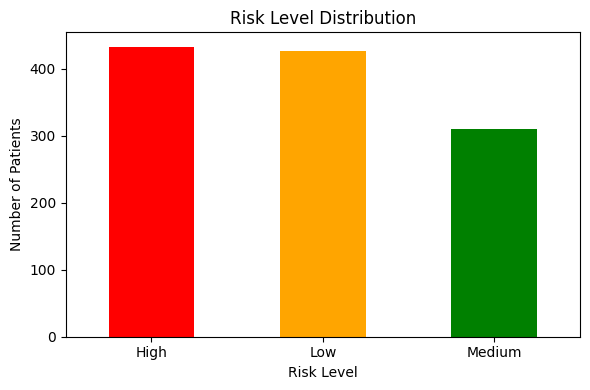

In [22]:
import matplotlib.pyplot as plt

risk_counts = analysis_table["risk_level"].value_counts()

plt.figure(figsize=(6,4))  # wider figure
risk_counts.plot(kind='bar', color=['red','orange','green'])
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)  # keep labels horizontal
plt.tight_layout()      # ensures labels fit in the figure
plt.savefig("risk_level_distribution.png", dpi=300)
plt.show()

### Encounters vs Age by Risk Level
Scatterplot showing how the number of encounters varies with patient age, colored by risk category (Low, Medium, High).

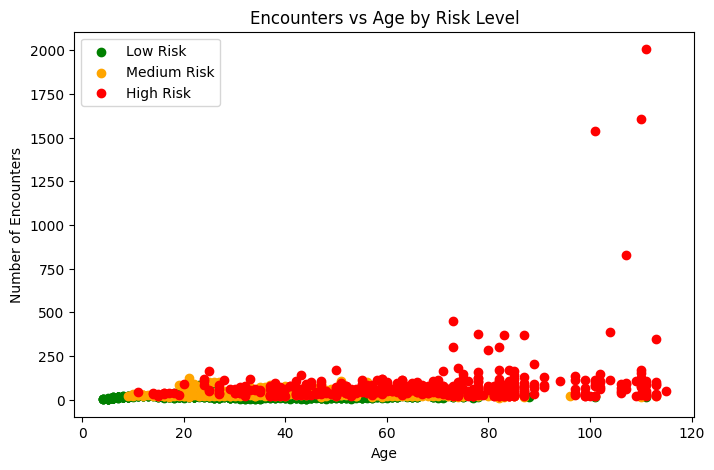

In [23]:
# Separate the data by risk level
low_risk = analysis_table[analysis_table["risk_level"]=="Low"]
medium_risk = analysis_table[analysis_table["risk_level"]=="Medium"]
high_risk = analysis_table[analysis_table["risk_level"]=="High"]

plt.figure(figsize=(8,5))

# Plot each risk group
plt.scatter(low_risk["age"], low_risk["encounter_count"], color='green', label='Low Risk')
plt.scatter(medium_risk["age"], medium_risk["encounter_count"], color='orange', label='Medium Risk')
plt.scatter(high_risk["age"], high_risk["encounter_count"], color='red', label='High Risk')

plt.title("Encounters vs Age by Risk Level")
plt.xlabel("Age")
plt.ylabel("Number of Encounters")
plt.legend()
plt.savefig("encounters_vs_age_by_risk.png")
plt.show()

### Average Medications per Age Group
Bar chart showing the average number of medications for each age group.

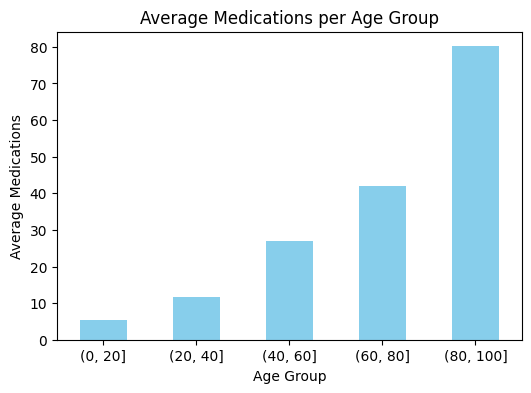

In [24]:
# Create age groups
age_groups = pd.cut(analysis_table["age"], bins=[0, 20, 40, 60, 80, 100])

# Compute average medications per age group
avg_medications = analysis_table.groupby(age_groups)["medication_count"].mean()

# Plot bar chart
plt.figure(figsize=(6,4))
avg_medications.plot(kind='bar', color='skyblue')

plt.title("Average Medications per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Medications")

# Rotate x-axis labels horizontally
plt.xticks(rotation=0)

# Save the figure
plt.savefig("avg_medications_age_group.png")
plt.show()

### Average Encounters by Number of Conditions
Bar chart showing how the average number of encounters changes with condition count. This highlights clinical intensity by disease burden.

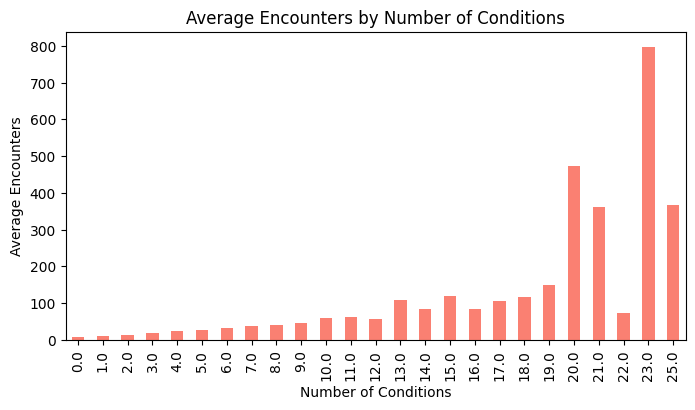

In [25]:
# Compute average encounters per number of conditions
encounter_by_conditions = analysis_table.groupby("condition_count")["encounter_count"].mean()

# Plot bar chart
plt.figure(figsize=(8,4))
encounter_by_conditions.plot(kind='bar', color='salmon')
plt.title("Average Encounters by Number of Conditions")
plt.xlabel("Number of Conditions")
plt.ylabel("Average Encounters")
plt.savefig("avg_encounters_conditions.png")
plt.show()

Data Quality Note

The dataset contains extreme medication counts (max >3000). 
This likely reflects cumulative historical prescriptions in the synthetic EHR dataset.

In real clinical analytics pipelines, additional preprocessing such as 
outlier detection or medication reconciliation would be performed.